In [10]:
#importing necessary libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as tkr
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns

In [11]:
#The session below will solely be used for defining functions


In [12]:
df=pd.read_csv("../cleaning/clean_greece_listings.csv")
df.shape

(18813, 28)

In [13]:
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,location_name,location_region,res_date,res_type,res_address,res_price,res_price_sqr,res_sqr,construction_year,levels,bedrooms,bathrooms,deleted,deleted_at,status,energyclass,auto_heating,solar,cooling,safe_door,gas,fireplace,furniture,student,parking,parking_flag,days_up
0,0,Παλαιό Φάληρο,Αττική,2021-06-18,Διαμέρισμα,"Παλαιό Φάληρο,Γήπεδα",89000,1618.0,55.0,1973.0,Υπερυψωμένο,1.0,1.0,1,2022-04-05,Ανακαινισμένο,Δ,1,0,1,1,0,0,0,0,NaN,0,291 days
1,1,Αχαρνές,Αττική,2022-03-30,Μεζονέτα,"Αχαρνές,Λαθέα",150000,1531.0,98.0,2010.0,4ος,2.0,1.0,1,2022-05-19,Νεόδμητο,Γ,0,0,0,0,0,1,0,0,Κλειστό parking,1,50 days
2,2,Παγκράτι,Αττική,2022-02-25,Διαμέρισμα,"Αθήνα,Παγκράτι",400000,3175.0,126.0,1990.0,3ος,3.0,1.0,1,2022-06-10,Άριστη,Δ,1,0,1,1,0,1,0,0,NaN,0,105 days
3,3,Αθήνα,Αττική,2022-03-21,Διαμέρισμα,"Αθήνα,Άγιος Παντελεήμονας",80000,941.0,85.0,1957.0,5ος,2.0,1.0,1,2022-03-23,Καλή,Ζ,1,0,0,1,0,0,0,1,NaN,0,2 days
4,4,Ίλιον,Αττική,2022-01-11,Διαμέρισμα,"Αθήνα,Άγιος Ελευθέριος",100000,2083.0,48.0,1996.0,1ος,1.0,1.0,1,2022-04-14,Καλή,Δ,1,0,0,1,0,0,0,0,NaN,0,93 days


# The code below will be used to plot exploratory variables

## 1. Levels

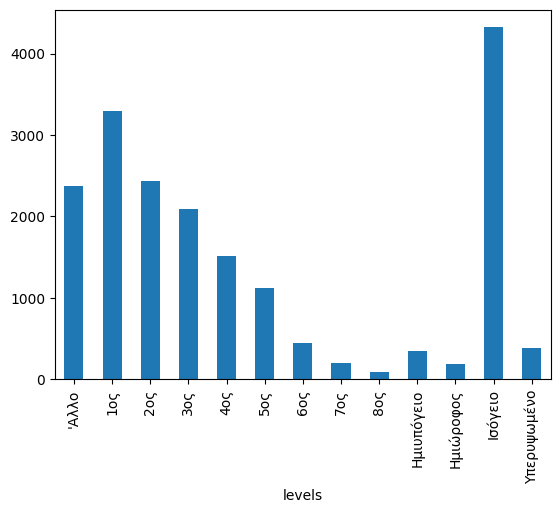

In [18]:
df.groupby("levels")["location_name"].count().plot.bar()
None

<Axes: xlabel='levels'>

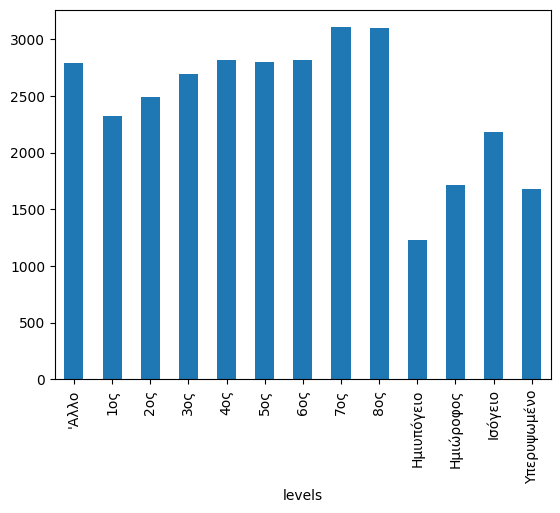

In [19]:
df.groupby("levels")["res_price_sqr"].mean().plot.bar()

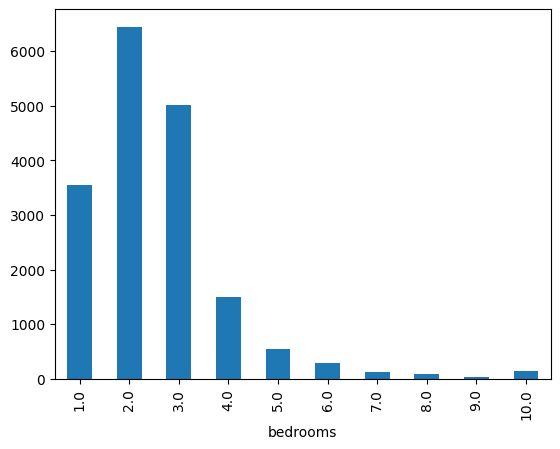

In [21]:
df.groupby("bedrooms")["location_name"].count().plot.bar()
None

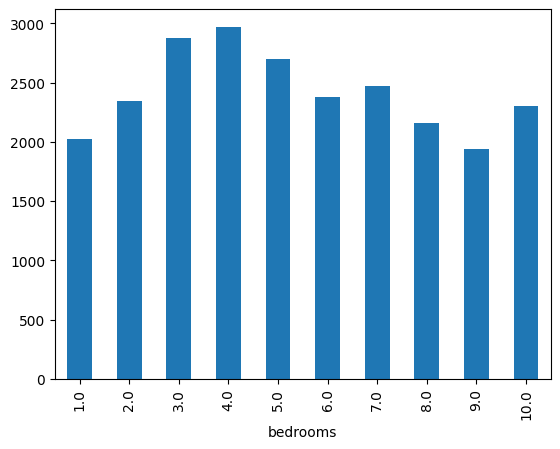

In [24]:
df.groupby("bedrooms")["res_price_sqr"].mean().plot.bar()
None

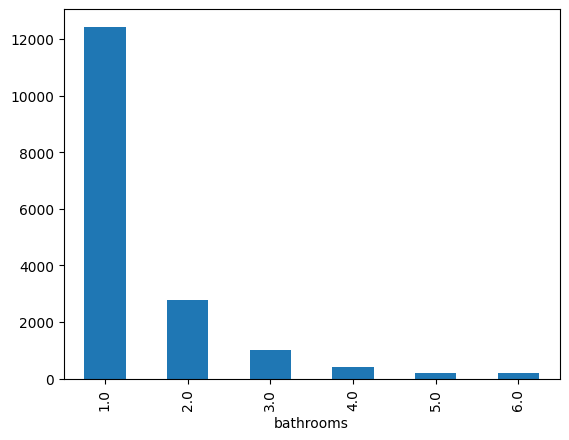

In [23]:
df.groupby("bathrooms")["location_name"].count().plot.bar()
None

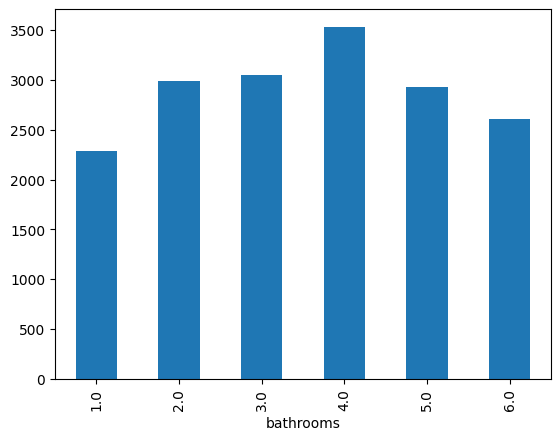

In [25]:
df.groupby("bathrooms")["res_price_sqr"].mean().plot.bar()
None

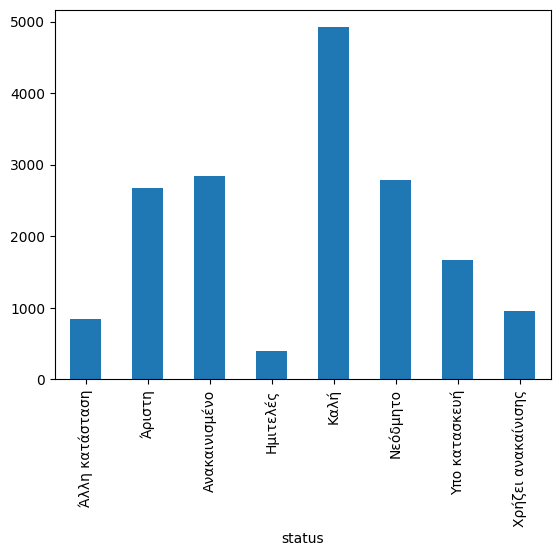

In [26]:
df.groupby("status")["location_name"].count().plot.bar()
None

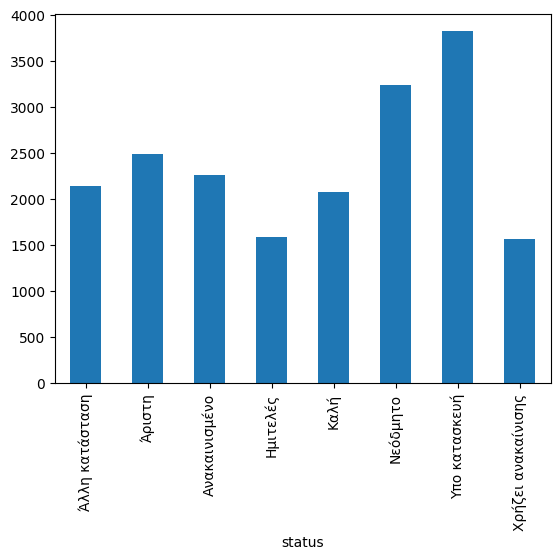

In [27]:
df.groupby("status")["res_price_sqr"].mean().plot.bar()
None

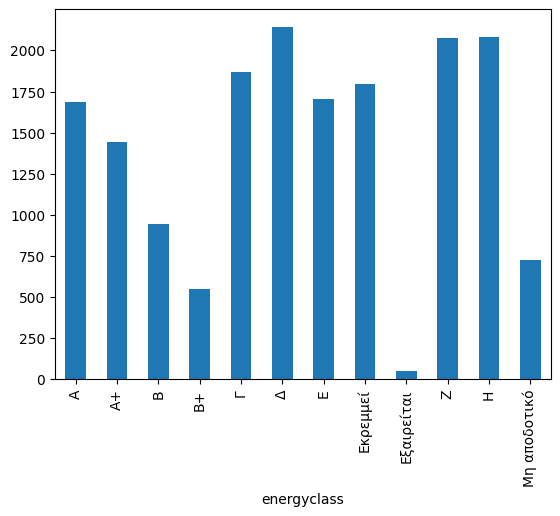

In [28]:
df.groupby("energyclass")["location_name"].count().plot.bar()
None

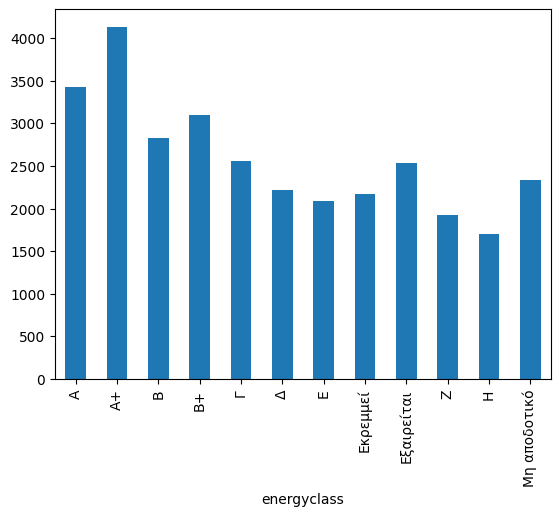

In [29]:
df.groupby("energyclass")["res_price_sqr"].mean().plot.bar()
None

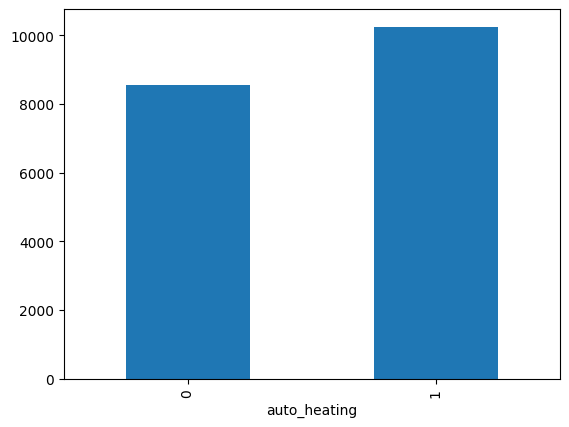

In [30]:
df.groupby("auto_heating")["location_name"].count().plot.bar()
None

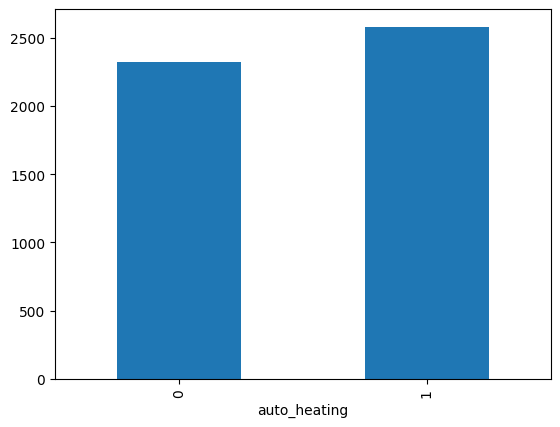

In [31]:
df.groupby("auto_heating")["res_price_sqr"].mean().plot.bar()
None

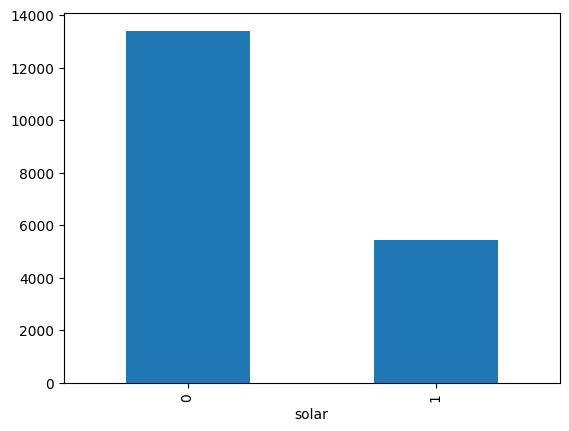

In [32]:
df.groupby("solar")["location_name"].count().plot.bar()
None

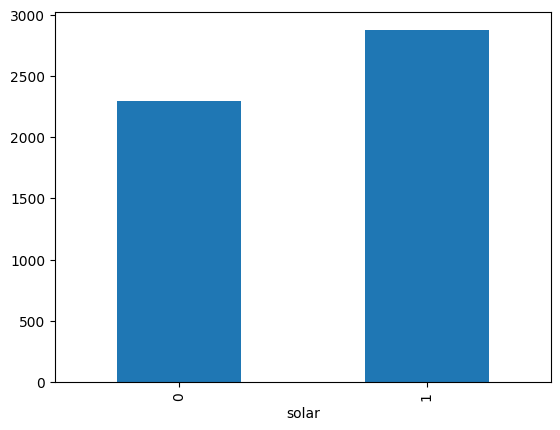

In [33]:
df.groupby("solar")["res_price_sqr"].mean().plot.bar()
None

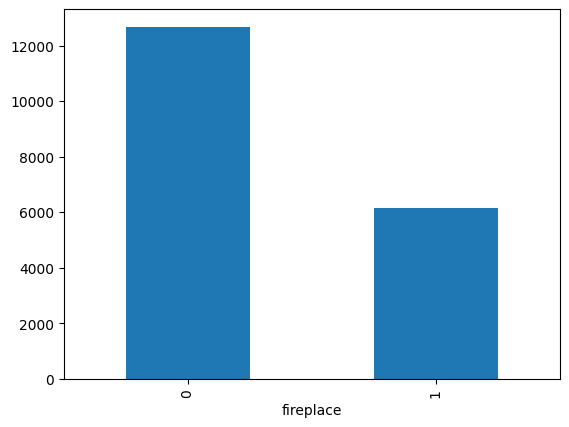

In [34]:
df.groupby("fireplace")["location_name"].count().plot.bar()
None

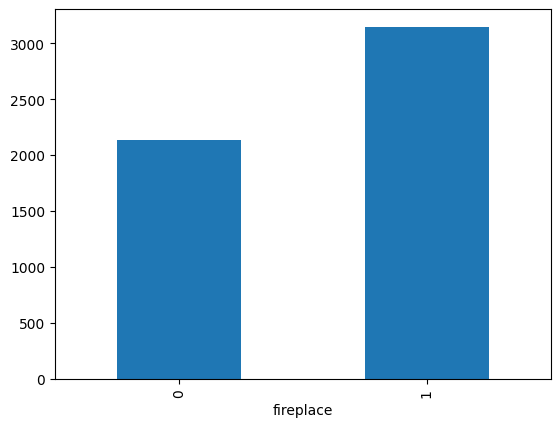

In [35]:
df.groupby("fireplace")["res_price_sqr"].mean().plot.bar()
None

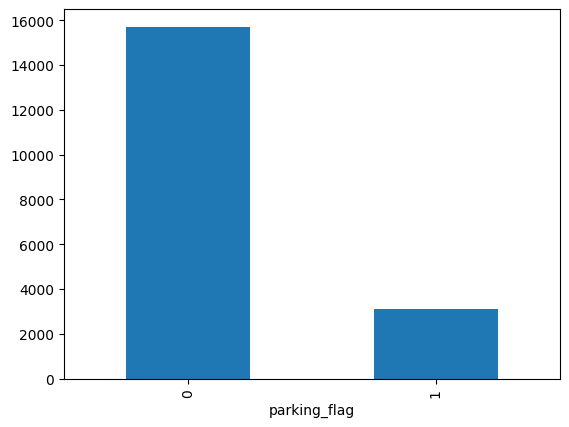

In [36]:
df.groupby("parking_flag")["location_name"].count().plot.bar()
None

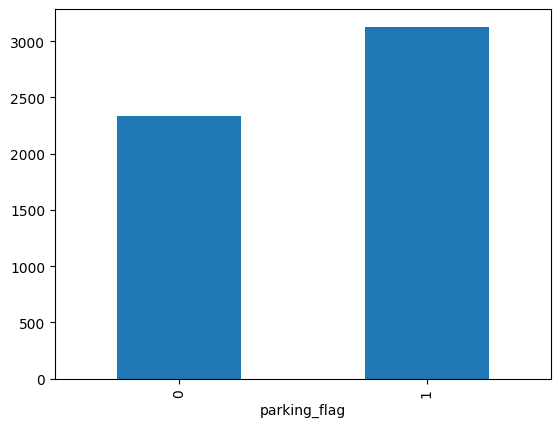

In [37]:
df.groupby("parking_flag")["res_price_sqr"].mean().plot.bar()
None

# start printing graphs

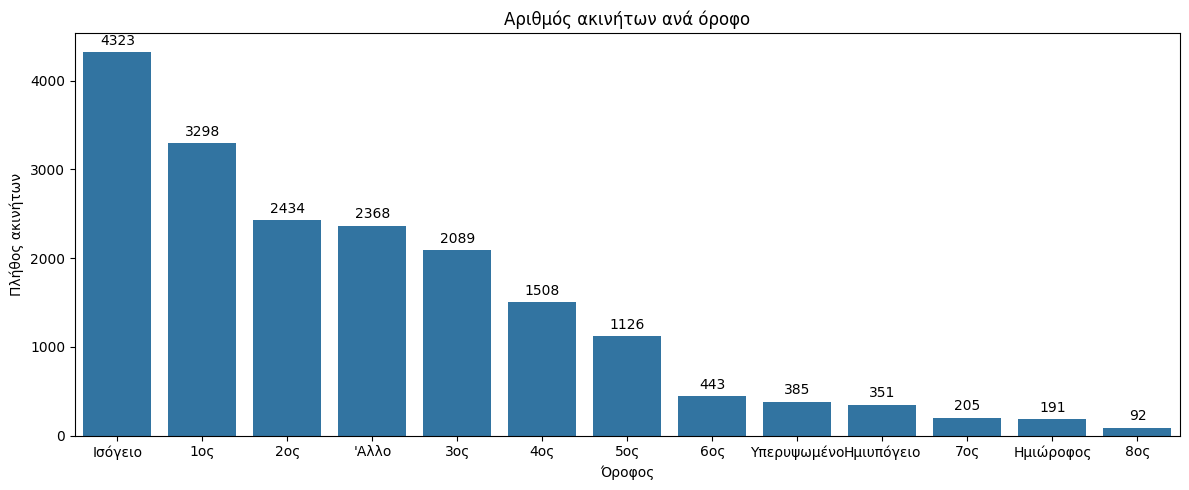

In [48]:
counts = (
    df.groupby("levels")["location_name"]
    .count()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=counts,
    x="levels",
    y="count"
)

ax.set_title("Αριθμός ακινήτων ανά όροφο")
ax.set_xlabel("Όροφος")
ax.set_ylabel("Πλήθος ακινήτων")

# Προσθήκη labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

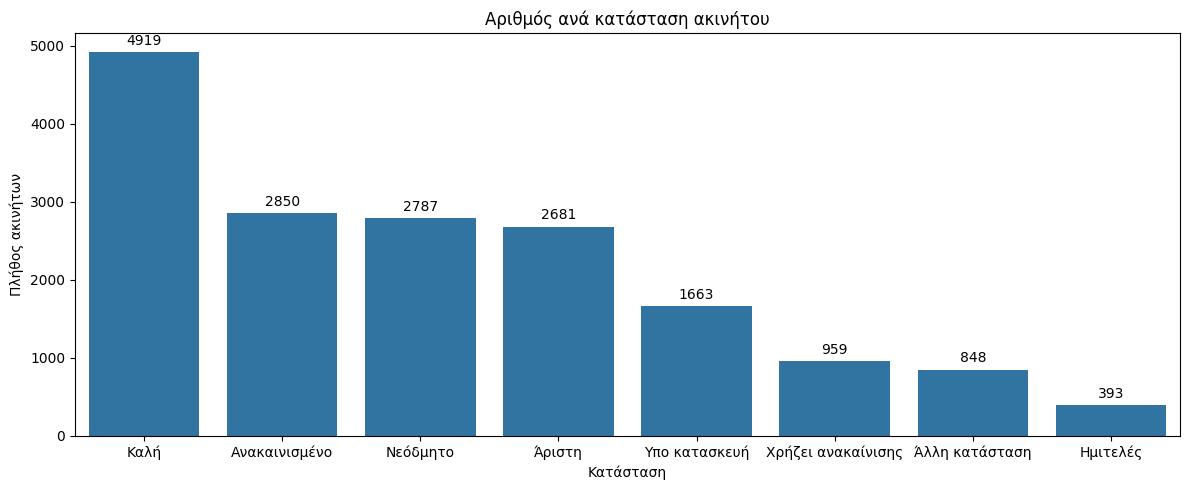

In [49]:
counts = (
    df.groupby("status")["location_name"]
    .count()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=counts,
    x="status",
    y="count"
)

ax.set_title("Αριθμός ανά κατάσταση ακινήτου")
ax.set_xlabel("Κατάσταση")
ax.set_ylabel("Πλήθος ακινήτων")

# Προσθήκη labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

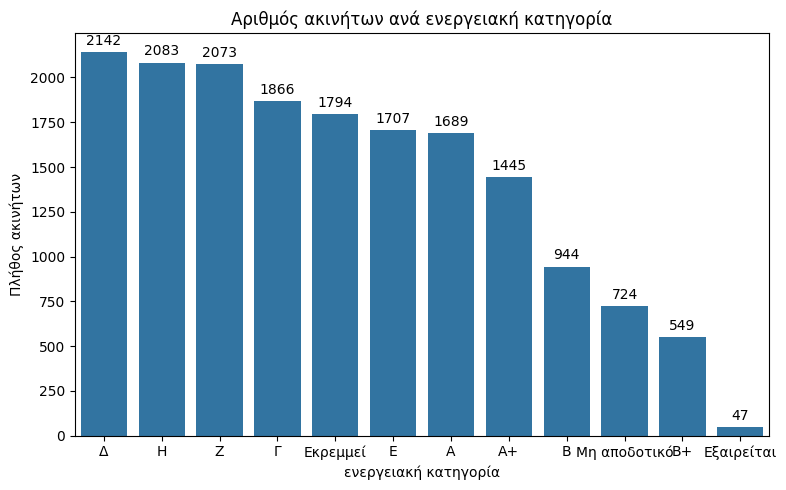

In [45]:
counts = (
    df.groupby("energyclass")["location_name"]
    .count()
    .reset_index(name="count")
    .sort_values("count", ascending= False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=counts,
    x="energyclass",
    y="count"
)

ax.set_title("Αριθμός ακινήτων ανά ενεργειακή κατηγορία")
ax.set_xlabel("ενεργειακή κατηγορία")
ax.set_ylabel("Πλήθος ακινήτων")

# Προσθήκη labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

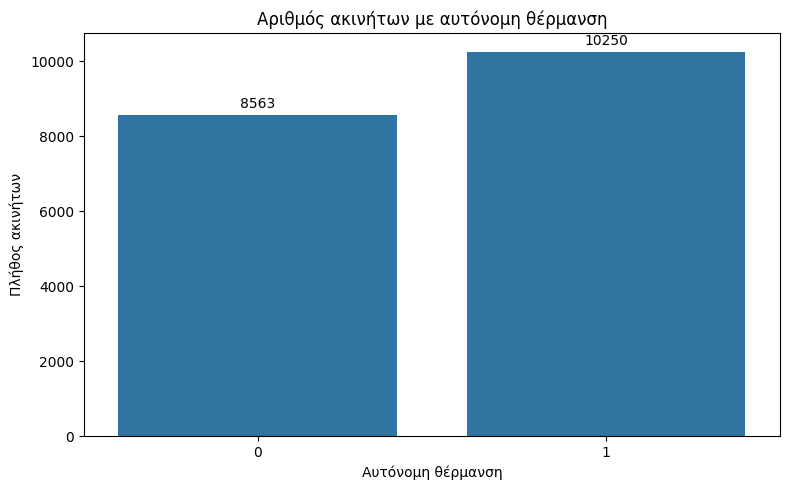

In [39]:
counts = (
    df.groupby("auto_heating")["location_name"]
    .count()
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=counts,
    x="auto_heating",
    y="count"
)

ax.set_title("Αριθμός ακινήτων με αυτόνομη θέρμανση")
ax.set_xlabel("Aυτόνομη θέρμανση")
ax.set_ylabel("Πλήθος ακινήτων")

# Προσθήκη labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

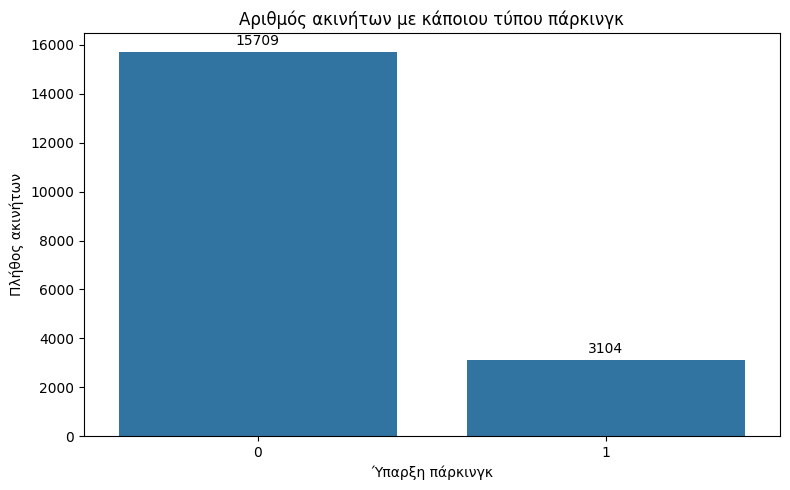

In [46]:
counts = (
    df.groupby("parking_flag")["location_name"]
    .count()
    .reset_index(name="count")
    .sort_values("count", ascending= False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=counts,
    x="parking_flag",
    y="count"
)

ax.set_title("Αριθμός ακινήτων με κάποιου τύπου πάρκινγκ")
ax.set_xlabel("Ύπαρξη πάρκινγκ")
ax.set_ylabel("Πλήθος ακινήτων")

# Προσθήκη labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

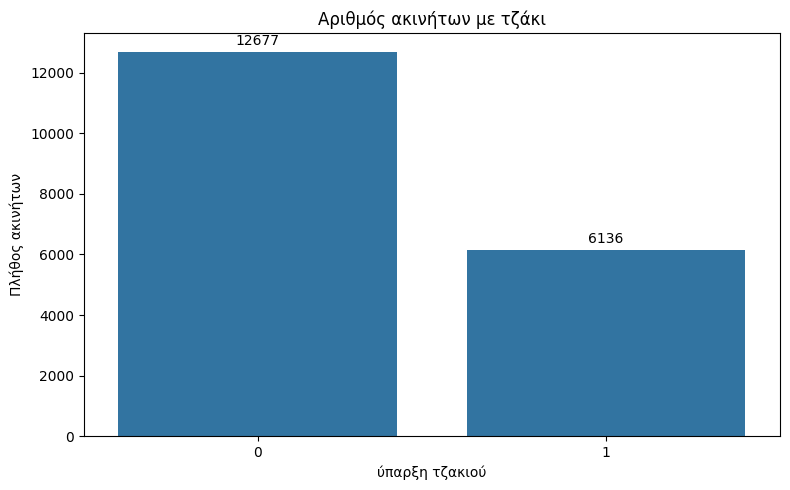

In [50]:
counts = (
    df.groupby("fireplace")["location_name"]
    .count()
    .reset_index(name="count")
    .sort_values("count", ascending= False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=counts,
    x="fireplace",
    y="count"
)

ax.set_title("Αριθμός ακινήτων με τζάκι")
ax.set_xlabel("ύπαρξη τζακιού")
ax.set_ylabel("Πλήθος ακινήτων")

# Προσθήκη labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()